# 🧪 Hypothesis Testing -- Deep Dive Notebook
### From first principles to real datasets, every major test covered

---

## 📚 Table of Contents

| # | Test | Use When | Example Dataset |
|---|------|----------|----------------|
| 0 | **Setup & Framework** | Always read first | -- |
| 1 | **One-Sample t-Test** | Compare a sample mean to a known value | Student exam scores |
| 2 | **Two-Sample t-Test (Independent)** | Compare means of two independent groups | Drug trial blood pressure |
| 3 | **Paired t-Test** | Before/after on the same subjects | Employee training programme |
| 4 | **One-Way ANOVA** | Compare means of 3+ groups | Sales across 4 city regions |
| 5 | **Chi-Square Test of Independence** | Association between two categorical variables | Ad campaign click-through |
| 6 | **Chi-Square Goodness of Fit** | Does data match an expected distribution? | Die fairness |
| 7 | **Pearson Correlation Test** | Is there a linear relationship? | Study hours vs exam score |
| 8 | **Mann-Whitney U (non-parametric)** | t-test without normality assumption | Customer ratings |
| 9 | **Wilcoxon Signed-Rank (non-parametric)** | Paired test without normality | App usability scores |
| 10 | **Choosing the Right Test** | Decision framework | -- |

---
> **How to use this notebook:** Every chapter follows the same structure --  
> *Theory -> Dataset -> Assumptions check -> Test -> Interpret -> Visualise*


## 0 ── Setup & The Universal Hypothesis Testing Framework

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
from scipy.stats import (norm, t, f, chi2, pearsonr,
                         shapiro, levene, mannwhitneyu,
                         wilcoxon, kruskal)
import warnings
warnings.filterwarnings('ignore')

# ── Plot style ─────────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor': '#f8f8f8',
    'axes.facecolor':   '#f8f8f8',
    'axes.spines.top':  False,
    'axes.spines.right':False,
    'axes.grid':        True,
    'grid.alpha':       0.35,
    'axes.labelsize':   11,
    'axes.titlesize':   13,
    'axes.titleweight': 'bold',
    'font.family':      'DejaVu Sans',
    'lines.linewidth':  2.2,
})
sns.set_palette("husl")

BLUE   = '#2980b9'
RED    = '#c0392b'
GREEN  = '#27ae60'
PURPLE = '#8e44ad'
ORANGE = '#e67e22'
GREY   = '#7f8c8d'
TEAL   = '#16a085'

np.random.seed(42)
print("[OK] All libraries loaded.")

[OK] All libraries loaded.


### The 5-Step Framework (used in every chapter)

```
STEP 1 -- State hypotheses     H₀ (null) and H1 (alternative)
STEP 2 -- Check assumptions    Normality? Equal variance? Independence?
STEP 3 -- Choose alpha             Typically 0.05; set BEFORE looking at p-value
STEP 4 -- Compute test stat    t, F, chi2, U, etc. and the p-value
STEP 5 -- Decide & interpret   Reject or fail to reject H₀ -- in plain English
```

### Anatomy of a Test Statistic

$$\text{test statistic} = \frac{\text{observed effect} - \text{expected effect under } H_0}{\text{standard error}}$$

Large test statistic -> data is far from what H₀ predicts -> small p-value -> reject H₀.


In [2]:
# ── Reusable helper: pretty results printer ────────────────────
def print_result(test_name, stat, stat_name, p_value, alpha=0.05, extra=None):
    sep = "─" * 55
    print(sep)
    print(f"  {test_name}")
    print(sep)
    print(f"  {stat_name:<25}: {stat:>10.4f}")
    print(f"  p-value              : {p_value:>10.4f}")
    print(f"  alpha (significance)     : {alpha:>10.2f}")
    if extra:
        for k, v in extra.items():
            print(f"  {k:<25}: {v}")
    print(sep)
    if p_value < alpha:
        print(f"  [OK] REJECT H₀  (p={p_value:.4f} < alpha={alpha})")
        print(f"     -> Statistically significant result.")
    else:
        print(f"  [X] FAIL TO REJECT H₀  (p={p_value:.4f} >= alpha={alpha})")
        print(f"     -> Not enough evidence against H₀.")
    print(sep)

# ── Reusable helper: assumption check ─────────────────────────
def check_normality(data, label=""):
    stat, p = shapiro(data)
    result = "[OK] Likely normal" if p > 0.05 else "⚠️  May not be normal"
    print(f"  Shapiro-Wilk [{label}]:  W={stat:.4f}, p={p:.4f}  -> {result}")
    return p > 0.05

def check_equal_variance(*groups, labels=None):
    stat, p = levene(*groups)
    result = "[OK] Variances likely equal" if p > 0.05 else "⚠️  Unequal variances -- use Welch's t"
    print(f"  Levene's test:  W={stat:.4f}, p={p:.4f}  -> {result}")
    return p > 0.05

print("Helper functions defined [OK]")

Helper functions defined [OK]


---
## Chapter 1 -- One-Sample t-Test

**Question:** Is the mean of a sample significantly different from a known/hypothesised value?

**Formula:**
$$t = \frac{\bar{x} - \mu_0}{s / \sqrt{n}}, \quad df = n-1$$

### 📘 Example: School Exam Scores
> The national average exam score is **65**. A teacher believes her class of 30 students performs differently.  
> She wants to test if the class mean differs from 65.

- **H₀:** mu = 65  
- **H1:** mu != 65  *(two-tailed)*  
- **alpha = 0.05**


In [3]:
# ── Dataset: 30 student exam scores ───────────────────────────
exam_scores = np.array([
    72, 68, 74, 61, 83, 79, 65, 70, 88, 55,
    76, 69, 71, 82, 63, 77, 80, 58, 73, 85,
    67, 74, 70, 66, 78, 81, 62, 75, 69, 84
])

df_exam = pd.DataFrame({'score': exam_scores})
print("── Exam Scores Dataset ──────────────────────────")
print(df_exam['score'].describe().round(2).to_string())
print(f"n : {len(exam_scores)}")
print(f" National mu: 65")

── Exam Scores Dataset ──────────────────────────
count    30.00
mean     72.50
std       8.33
min      55.00
25%      67.25
50%      72.50
75%      78.75
max      88.00
n : 30
 National mu: 65


In [4]:
# ── STEP 2: Check assumptions ──────────────────────────────────
print("── Assumption Checks ────────────────────────────")
check_normality(exam_scores, "exam scores")

── Assumption Checks ────────────────────────────
  Shapiro-Wilk [exam scores]:  W=0.9885, p=0.9812  -> [OK] Likely normal


True

In [6]:
# ── STEP 4: Run the test ───────────────────────────────────────
mu_0 = 65
t_stat, p_value = stats.ttest_1samp(exam_scores, mu_0)

print_result(
    "One-Sample t-Test: Exam Scores vs National Avg (mu=65)",
    t_stat, "t-statistic", p_value,
    extra={
        "Sample mean": f"{exam_scores.mean():.2f}",
        "Std dev":     f"{exam_scores.std(ddof=1):.2f}",
        "n":           f"{len(exam_scores)}",
        "df":          f"{len(exam_scores)-1}",
    }
)

# 95% confidence interval
se = exam_scores.std(ddof=1) / np.sqrt(len(exam_scores))
t_crit = stats.t.ppf(0.975, df=len(exam_scores)-1)
ci_lo = exam_scores.mean() - t_crit * se
ci_hi = exam_scores.mean() + t_crit * se
print(f"95% CI for mu: ({ci_lo:.2f},  {ci_hi:.2f})")
print(f"  Since 65 is {'inside' if ci_lo <= 65 <= ci_hi else 'OUTSIDE'} the CI, "
f"this {'supports' if ci_lo <= 65 <= ci_hi else 'contradicts'} failing to reject H₀.")

───────────────────────────────────────────────────────
  One-Sample t-Test: Exam Scores vs National Avg (mu=65)
───────────────────────────────────────────────────────
  t-statistic              :     4.9324
  p-value              :     0.0000
  alpha (significance)     :       0.05
  Sample mean              : 72.50
  Std dev                  : 8.33
  n                        : 30
  df                       : 29
───────────────────────────────────────────────────────
  [OK] REJECT H₀  (p=0.0000 < alpha=0.05)
     -> Statistically significant result.
───────────────────────────────────────────────────────
95% CI for mu: (69.39,  75.61)
  Since 65 is OUTSIDE the CI, this contradicts failing to reject H₀.


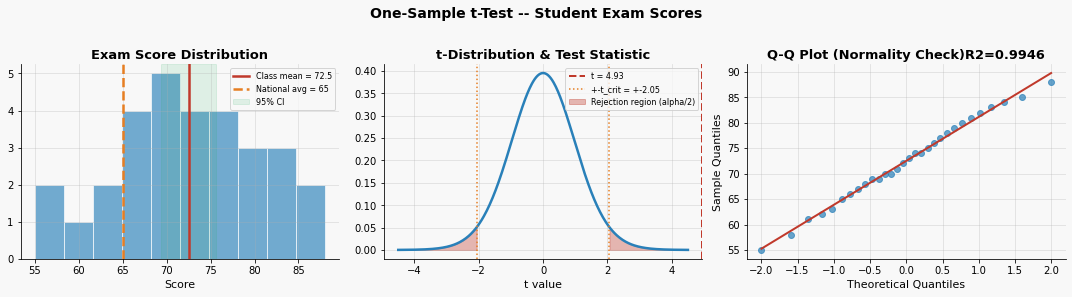

In [7]:
# ── Visualisation ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# 1. Histogram with annotations
axes[0].hist(exam_scores, bins=10, color=BLUE, alpha=0.65, edgecolor='white')
axes[0].axvline(exam_scores.mean(), color=RED, linewidth=2.5,
                label=f'Class mean = {exam_scores.mean():.1f}')
axes[0].axvline(mu_0, color=ORANGE, linewidth=2.5, linestyle='--',
                label=f'National avg = {mu_0}')
axes[0].axvspan(ci_lo, ci_hi, alpha=0.12, color=GREEN, label='95% CI')
axes[0].set_title('Exam Score Distribution'); axes[0].set_xlabel('Score')
axes[0].legend(fontsize=8)

# 2. t-distribution with rejection regions and test statistic
df_t = len(exam_scores) - 1
x_t = np.linspace(-4.5, 4.5, 400)
y_t = stats.t.pdf(x_t, df_t)
t_crit_plot = stats.t.ppf(0.975, df_t)

axes[1].plot(x_t, y_t, color=BLUE, linewidth=2.5)
for mask, lbl in [(x_t <= -t_crit_plot, 'Rejection region (alpha/2)'),
                  (x_t >=  t_crit_plot, None)]:
    axes[1].fill_between(x_t, y_t, where=mask, alpha=0.35, color=RED,
                         label=lbl or '')
axes[1].axvline(t_stat, color=RED, linestyle='--', linewidth=2,
                label=f't = {t_stat:.2f}')
axes[1].axvline(-t_crit_plot, color=ORANGE, linestyle=':', linewidth=1.5)
axes[1].axvline( t_crit_plot, color=ORANGE, linestyle=':', linewidth=1.5,
                label=f'+-t_crit = +-{t_crit_plot:.2f}')
axes[1].set_title('t-Distribution & Test Statistic')
axes[1].set_xlabel('t value'); axes[1].legend(fontsize=8)

# 3. QQ-plot for normality check
(osm, osr), (slope, intercept, r) = stats.probplot(exam_scores)
axes[2].plot(osm, osr, 'o', color=BLUE, alpha=0.7, markersize=6)
axes[2].plot(osm, slope*np.array(osm)+intercept, color=RED, linewidth=2)
axes[2].set_title(f'Q-Q Plot (Normality Check)R2={r**2:.4f}')
axes[2].set_xlabel('Theoretical Quantiles'); axes[2].set_ylabel('Sample Quantiles')

plt.suptitle('One-Sample t-Test -- Student Exam Scores', fontsize=14,
             fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()

---
## Chapter 2 -- Two-Sample Independent t-Test

**Question:** Do two independent groups have the same population mean?

**Formula (Welch's -- doesn't assume equal variance):**
$$t = \frac{\bar{x}_1 - \bar{x}_2}{\sqrt{\frac{s_1^2}{n_1} + \frac{s_2^2}{n_2}}}$$

### 💊 Example: Drug Trial -- Blood Pressure
> 60 patients randomised into two groups.  
> **Control** (n=30): standard treatment  
> **Drug** (n=30): new drug  
> Outcome: systolic blood pressure reduction after 8 weeks.

- **H₀:** mu_drug = mu_control *(no difference)*  
- **H1:** mu_drug > mu_control *(drug reduces BP more)* -> **one-tailed right**  
- **alpha = 0.05**


In [8]:
# ── Dataset: Blood pressure reductions (mmHg) ─────────────────
np.random.seed(123)
control = np.round(np.random.normal(loc=5.0, scale=3.5, size=30), 1)
drug    = np.round(np.random.normal(loc=7.8, scale=3.8, size=30), 1)

df_bp = pd.DataFrame({
    'reduction': np.concatenate([control, drug]),
    'group':     ['Control']*30 + ['Drug']*30
})

print("── Blood Pressure Dataset ───────────────────────")
print(df_bp.groupby('group')['reduction'].describe().round(2).to_string())
print(f"Mean diff (Drug - Control): {drug.mean() - control.mean():.3f} mmHg")

── Blood Pressure Dataset ───────────────────────
         count  mean   std  min   25%  50%    75%   max
group                                                  
Control   30.0  5.16  4.16 -3.5  2.15  4.0   8.50  12.7
Drug      30.0  8.34  4.68 -2.8  4.88  8.4  11.45  16.9
Mean diff (Drug - Control): 3.183 mmHg


In [9]:
# ── STEP 2: Assumptions ────────────────────────────────────────
print("── Assumption Checks ────────────────────────────")
check_normality(control, "Control")
check_normality(drug,    "Drug")
check_equal_variance(control, drug)

── Assumption Checks ────────────────────────────
  Shapiro-Wilk [Control]:  W=0.9624, p=0.3553  -> [OK] Likely normal
  Shapiro-Wilk [Drug]:  W=0.9874, p=0.9712  -> [OK] Likely normal
  Levene's test:  W=0.1521, p=0.6979  -> [OK] Variances likely equal


True

In [10]:
# ── STEP 4: Run the test (one-tailed) ─────────────────────────
t_stat, p_two = stats.ttest_ind(drug, control, equal_var=False)  # Welch's
p_one = p_two / 2  # one-tailed (drug > control direction)

print_result(
    "Two-Sample t-Test (Welch's): Drug vs Control BP Reduction",
    t_stat, "t-statistic", p_one,
    extra={
        "Control mean": f"{control.mean():.3f} mmHg",
        "Drug mean":    f"{drug.mean():.3f} mmHg",
        "Mean diff":    f"{drug.mean()-control.mean():.3f} mmHg",
        "Cohen's d":    f"{(drug.mean()-control.mean()) / np.sqrt((drug.std()**2+control.std()**2)/2):.3f}",
    }
)

───────────────────────────────────────────────────────
  Two-Sample t-Test (Welch's): Drug vs Control BP Reduction
───────────────────────────────────────────────────────
  t-statistic              :     2.7847
  p-value              :     0.0036
  alpha (significance)     :       0.05
  Control mean             : 5.160 mmHg
  Drug mean                : 8.343 mmHg
  Mean diff                : 3.183 mmHg
  Cohen's d                : 0.731
───────────────────────────────────────────────────────
  [OK] REJECT H₀  (p=0.0036 < alpha=0.05)
     -> Statistically significant result.
───────────────────────────────────────────────────────


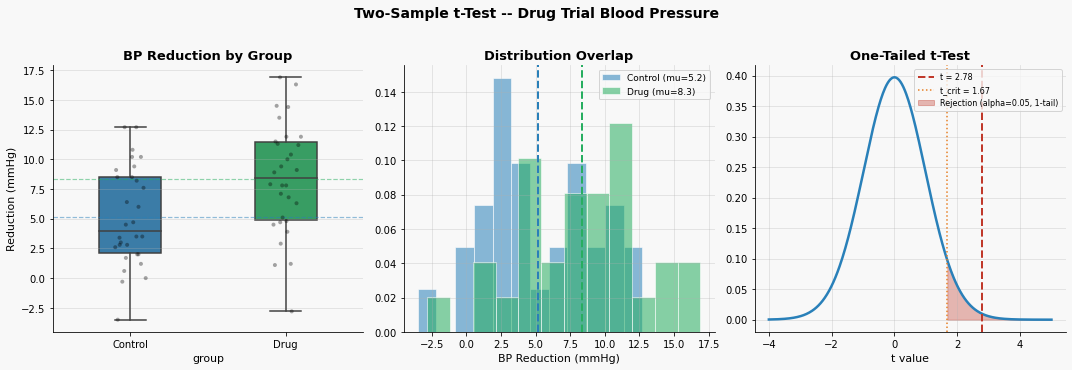

In [11]:
# ── Visualisation ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# 1. Box + strip plot
sns.boxplot(data=df_bp, x='group', y='reduction', palette={'Control': BLUE, 'Drug': GREEN},
            ax=axes[0], width=0.4, linewidth=1.5)
sns.stripplot(data=df_bp, x='group', y='reduction', color='black', alpha=0.35,
              size=4, jitter=True, ax=axes[0])
axes[0].axhline(df_bp.groupby('group')['reduction'].mean()['Control'],
                color=BLUE, linestyle='--', alpha=0.5, linewidth=1.2)
axes[0].axhline(df_bp.groupby('group')['reduction'].mean()['Drug'],
                color=GREEN, linestyle='--', alpha=0.5, linewidth=1.2)
axes[0].set_title('BP Reduction by Group'); axes[0].set_ylabel('Reduction (mmHg)')

# 2. Overlapping histograms
axes[1].hist(control, bins=12, color=BLUE,  alpha=0.55, label=f'Control (mu={control.mean():.1f})',
             edgecolor='white', density=True)
axes[1].hist(drug,    bins=12, color=GREEN, alpha=0.55, label=f'Drug (mu={drug.mean():.1f})',
             edgecolor='white', density=True)
axes[1].axvline(control.mean(), color=BLUE,  linestyle='--', linewidth=2)
axes[1].axvline(drug.mean(),    color=GREEN, linestyle='--', linewidth=2)
axes[1].set_title('Distribution Overlap'); axes[1].set_xlabel('BP Reduction (mmHg)')
axes[1].legend(fontsize=9)

# 3. t-distribution one-tailed
df_t2 = len(control) + len(drug) - 2
x_t = np.linspace(-4, 5, 400)
y_t = stats.t.pdf(x_t, df_t2)
t_crit_1 = stats.t.ppf(0.95, df_t2)
axes[2].plot(x_t, y_t, color=BLUE, linewidth=2.5)
axes[2].fill_between(x_t, y_t, where=(x_t >= t_crit_1), alpha=0.35, color=RED,
                     label=f'Rejection (alpha=0.05, 1-tail)')
axes[2].axvline(t_stat, color=RED, linestyle='--', linewidth=2, label=f't = {t_stat:.2f}')
axes[2].axvline(t_crit_1, color=ORANGE, linestyle=':', linewidth=1.5,
                label=f't_crit = {t_crit_1:.2f}')
axes[2].set_title('One-Tailed t-Test'); axes[2].set_xlabel('t value')
axes[2].legend(fontsize=8)

plt.suptitle('Two-Sample t-Test -- Drug Trial Blood Pressure', fontsize=14,
             fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()

---
## Chapter 3 -- Paired t-Test

**Question:** Did scores change between two measurements on the **same subjects**?

The key insight: you test the *difference* (after - before) against zero.

$$t = \frac{\bar{d}}{s_d / \sqrt{n}}, \quad \text{where } d_i = x_{\text{after},i} - x_{\text{before},i}$$

### 🏢 Example: Employee Training Programme
> 25 employees took a productivity test **before** and **after** a 4-week training.  
> Did training improve productivity scores?

- **H₀:** mu_d = 0 *(no change)*  
- **H1:** mu_d > 0 *(training improved scores)* -> **one-tailed**  
- **alpha = 0.05**


In [12]:
# ── Dataset: Productivity scores before/after training ─────────
np.random.seed(77)
n_emp = 25
before = np.round(np.random.normal(60, 10, n_emp))
improvement = np.round(np.random.normal(6, 8, n_emp))   # avg +6 points
after = np.clip(before + improvement, 0, 100)

df_train = pd.DataFrame({
    'employee': [f'E{i+1:02d}' for i in range(n_emp)],
    'before': before,
    'after':  after,
    'diff':   after - before
})

print("── Training Dataset (first 10 rows) ─────────────")
print(df_train.head(10).to_string(index=False))
print(f"Mean before : {before.mean():.2f}")
print(f"  Mean after  : {after.mean():.2f}")
print(f"  Mean diff   : {df_train['diff'].mean():.2f}")
print(f"  Std of diff : {df_train['diff'].std():.2f}")

── Training Dataset (first 10 rows) ─────────────
employee  before  after  diff
     E01    62.0   82.0  20.0
     E02    67.0   67.0   0.0
     E03    54.0   56.0   2.0
     E04    64.0   64.0   0.0
     E05    65.0   73.0   8.0
     E06    40.0   36.0  -4.0
     E07    63.0   56.0  -7.0
     E08    44.0   53.0   9.0
     E09    76.0   82.0   6.0
     E10    53.0   52.0  -1.0
Mean before : 57.32
  Mean after  : 61.72
  Mean diff   : 4.40
  Std of diff : 6.42


In [13]:
# ── STEP 2: Check normality of DIFFERENCES ────────────────────
print("── Assumption Check (normality of differences) ──")
check_normality(df_train['diff'].values, "diff (after-before)")

── Assumption Check (normality of differences) ──
  Shapiro-Wilk [diff (after-before)]:  W=0.9724, p=0.7064  -> [OK] Likely normal


True

In [14]:
# ── STEP 4: Paired t-test ──────────────────────────────────────
t_stat, p_two = stats.ttest_rel(after, before)
p_one = p_two / 2  # one-tailed: after > before

print_result(
    "Paired t-Test: Employee Productivity Before vs After Training",
    t_stat, "t-statistic", p_one,
    extra={
        "Mean difference": f"{df_train['diff'].mean():.3f} points",
        "Std of diff":     f"{df_train['diff'].std():.3f}",
        "n (pairs)":       f"{n_emp}",
        "df":              f"{n_emp - 1}",
    }
)

───────────────────────────────────────────────────────
  Paired t-Test: Employee Productivity Before vs After Training
───────────────────────────────────────────────────────
  t-statistic              :     3.4289
  p-value              :     0.0011
  alpha (significance)     :       0.05
  Mean difference          : 4.400 points
  Std of diff              : 6.416
  n (pairs)                : 25
  df                       : 24
───────────────────────────────────────────────────────
  [OK] REJECT H₀  (p=0.0011 < alpha=0.05)
     -> Statistically significant result.
───────────────────────────────────────────────────────


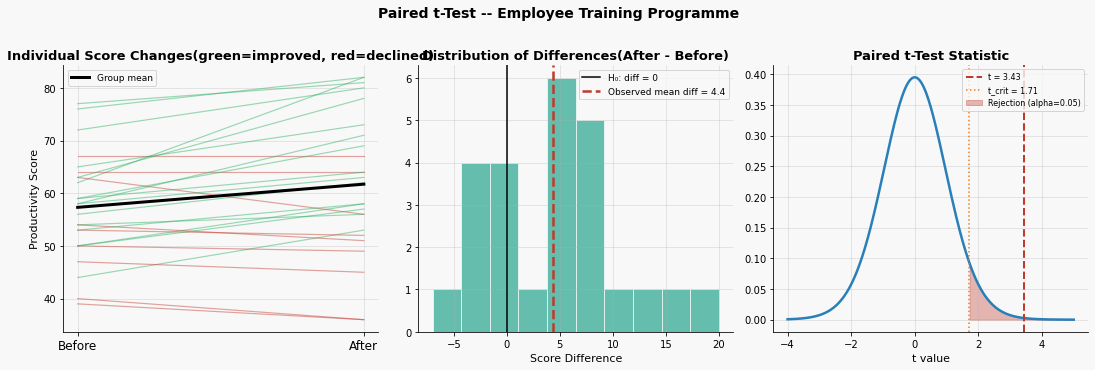

In [15]:
# ── Visualisation ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# 1. Slopegraph -- before/after per employee
colors_slope = [GREEN if d > 0 else RED for d in df_train['diff']]
for i, row in df_train.iterrows():
    axes[0].plot([0, 1], [row['before'], row['after']],
                 color=GREEN if row['diff'] > 0 else RED, alpha=0.45, linewidth=1.2)
axes[0].plot([0, 1], [before.mean(), after.mean()],
             color='black', linewidth=3, zorder=5, label='Group mean')
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(['Before', 'After'], fontsize=12)
axes[0].set_ylabel('Productivity Score')
axes[0].set_title('Individual Score Changes(green=improved, red=declined)')
axes[0].legend(fontsize=9)

# 2. Distribution of differences
diffs = df_train['diff'].values
axes[1].hist(diffs, bins=10, color=TEAL, alpha=0.65, edgecolor='white')
axes[1].axvline(0, color='black', linestyle='-', linewidth=1.5, label='H₀: diff = 0')
axes[1].axvline(diffs.mean(), color=RED, linestyle='--', linewidth=2.5,
                label=f'Observed mean diff = {diffs.mean():.1f}')
axes[1].set_title('Distribution of Differences(After - Before)')
axes[1].set_xlabel('Score Difference'); axes[1].legend(fontsize=9)

# 3. t-distribution
df_t3 = n_emp - 1
x_t = np.linspace(-4, 5, 400)
axes[2].plot(x_t, stats.t.pdf(x_t, df_t3), color=BLUE, linewidth=2.5)
t_crit_p = stats.t.ppf(0.95, df_t3)
axes[2].fill_between(x_t, stats.t.pdf(x_t, df_t3), where=(x_t >= t_crit_p),
                     alpha=0.35, color=RED, label=f'Rejection (alpha=0.05)')
axes[2].axvline(t_stat, color=RED, linestyle='--', linewidth=2,
                label=f't = {t_stat:.2f}')
axes[2].axvline(t_crit_p, color=ORANGE, linestyle=':', linewidth=1.5,
                label=f't_crit = {t_crit_p:.2f}')
axes[2].set_title('Paired t-Test Statistic')
axes[2].set_xlabel('t value'); axes[2].legend(fontsize=8)

plt.suptitle('Paired t-Test -- Employee Training Programme', fontsize=14,
             fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()

---
## Chapter 4 -- One-Way ANOVA

**Question:** Do 3 or more groups have the same mean? (Running multiple t-tests inflates Type I error -- ANOVA fixes this.)

**Idea:** Partition total variance into *between-group* variance and *within-group* variance.

$$F = \frac{\text{Variance between groups}}{\text{Variance within groups}} = \frac{MS_{between}}{MS_{within}}$$

If H₀ is true (all means equal), F ≈ 1. Large F -> groups differ significantly.

### 🏙️ Example: Sales Performance Across 4 City Regions
> A retail company tests whether average weekly sales differ across Mumbai, Delhi, Bangalore, and Chennai.

- **H₀:** mu_Mumbai = mu_Delhi = mu_Bangalore = mu_Chennai  
- **H1:** At least one mean differs  
- **alpha = 0.05**

> ⚠️ ANOVA only tells you *that* at least one group differs -- not *which* ones. Use **post-hoc tests** (Tukey HSD) for that.


In [16]:
# ── Dataset: Weekly sales by city (₹ lakhs) ───────────────────
np.random.seed(9)
mumbai    = np.round(np.random.normal(42, 6, 25), 1)
delhi     = np.round(np.random.normal(38, 7, 25), 1)
bangalore = np.round(np.random.normal(45, 5, 25), 1)
chennai   = np.round(np.random.normal(40, 8, 25), 1)

df_sales = pd.DataFrame({
    'sales': np.concatenate([mumbai, delhi, bangalore, chennai]),
    'city':  ['Mumbai']*25 + ['Delhi']*25 + ['Bangalore']*25 + ['Chennai']*25
})

print("── Sales Dataset by City ────────────────────────")
print(df_sales.groupby('city')['sales'].agg(['mean','std','count']).round(2).to_string())

── Sales Dataset by City ────────────────────────
            mean   std  count
city                         
Bangalore  42.80  6.29     25
Chennai    41.20  6.43     25
Delhi      38.32  8.03     25
Mumbai     43.15  5.18     25


In [17]:
# ── STEP 2: Assumptions ────────────────────────────────────────
print("── Assumption Checks ────────────────────────────")
for city, grp in df_sales.groupby('city')['sales']:
    check_normality(grp.values, city)
check_equal_variance(mumbai, delhi, bangalore, chennai)

── Assumption Checks ────────────────────────────
  Shapiro-Wilk [Bangalore]:  W=0.9666, p=0.5599  -> [OK] Likely normal
  Shapiro-Wilk [Chennai]:  W=0.9511, p=0.2654  -> [OK] Likely normal
  Shapiro-Wilk [Delhi]:  W=0.9729, p=0.7190  -> [OK] Likely normal
  Shapiro-Wilk [Mumbai]:  W=0.9807, p=0.8979  -> [OK] Likely normal
  Levene's test:  W=0.8426, p=0.4738  -> [OK] Variances likely equal


True

In [18]:
# ── STEP 4: One-Way ANOVA ──────────────────────────────────────
f_stat, p_value = stats.f_oneway(mumbai, delhi, bangalore, chennai)

# Manual ANOVA table
groups = [mumbai, delhi, bangalore, chennai]
grand_mean = df_sales['sales'].mean()
k = len(groups)
N = sum(len(g) for g in groups)

SS_between = sum(len(g) * (g.mean() - grand_mean)**2 for g in groups)
SS_within  = sum(((g - g.mean())**2).sum() for g in groups)
SS_total   = SS_between + SS_within
df_between = k - 1
df_within  = N - k
MS_between = SS_between / df_between
MS_within  = SS_within  / df_within

print("── ANOVA Table ──────────────────────────────────")
print(f"  {'Source':<15} {'SS':>10} {'df':>6} {'MS':>10} {'F':>8}")
print(f"  {'─'*55}")
print(f"  {'Between groups':<15} {SS_between:>10.3f} {df_between:>6} {MS_between:>10.3f} {f_stat:>8.3f}")
print(f"  {'Within groups':<15} {SS_within:>10.3f} {df_within:>6} {MS_within:>10.3f}")
print(f"  {'Total':<15} {SS_total:>10.3f} {N-1:>6}")
print()

print_result("One-Way ANOVA: Sales Across City Regions",
             f_stat, "F-statistic", p_value)

── ANOVA Table ──────────────────────────────────
  Source                  SS     df         MS        F
  ───────────────────────────────────────────────────────
  Between groups     363.472      3    121.157    2.814
  Within groups     4133.998     96     43.062
  Total             4497.470     99

───────────────────────────────────────────────────────
  One-Way ANOVA: Sales Across City Regions
───────────────────────────────────────────────────────
  F-statistic              :     2.8135
  p-value              :     0.0434
  alpha (significance)     :       0.05
───────────────────────────────────────────────────────
  [OK] REJECT H₀  (p=0.0434 < alpha=0.05)
     -> Statistically significant result.
───────────────────────────────────────────────────────


In [19]:
# ── Post-hoc: Tukey HSD ────────────────────────────────────────
from itertools import combinations

city_names = ['Mumbai', 'Delhi', 'Bangalore', 'Chennai']
city_data  = [mumbai, delhi, bangalore, chennai]

print("── Tukey HSD Post-Hoc Test ──────────────────────")
print(f"  {'Comparison':<25} {'Diff':>8} {'p-value':>10} {'Significant':>12}")
print(f"  {'─'*60}")

# Simple pairwise t-tests with Bonferroni correction
n_comparisons = len(list(combinations(range(k), 2)))
for i, j in combinations(range(k), 2):
    t_s, p_s = stats.ttest_ind(city_data[i], city_data[j])
    p_bonf = min(p_s * n_comparisons, 1.0)   # Bonferroni corrected
    diff = city_data[i].mean() - city_data[j].mean()
    sig = "[OK] Yes" if p_bonf < 0.05 else "[X] No"
    print(f"  {city_names[i]} vs {city_names[j]:<14} {diff:>8.2f} {p_bonf:>10.4f} {sig:>12}")

── Tukey HSD Post-Hoc Test ──────────────────────
  Comparison                    Diff    p-value  Significant
  ────────────────────────────────────────────────────────────
  Mumbai vs Delhi              4.83     0.0896       [X] No
  Mumbai vs Bangalore          0.35     1.0000       [X] No
  Mumbai vs Chennai            1.95     1.0000       [X] No
  Delhi vs Bangalore         -4.48     0.1979       [X] No
  Delhi vs Chennai           -2.88     1.0000       [X] No
  Bangalore vs Chennai            1.60     1.0000       [X] No


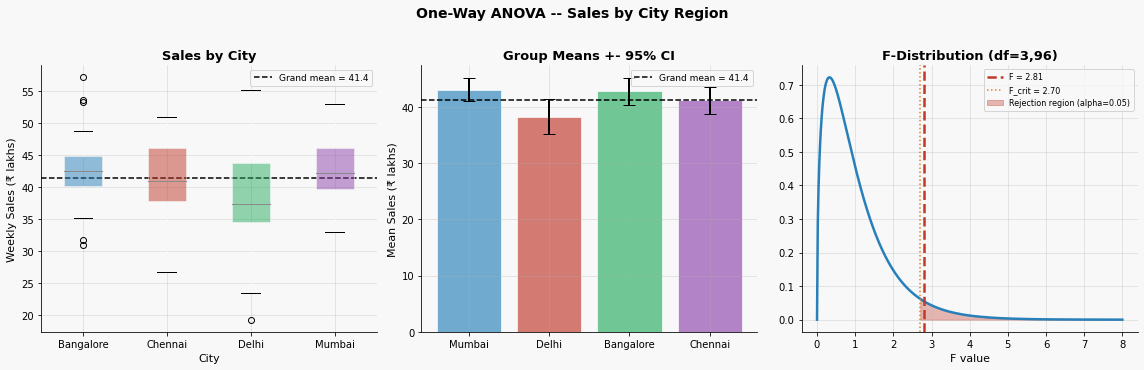

In [20]:
# ── Visualisation ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 1. Box plots
colors_city = [BLUE, RED, GREEN, PURPLE]
bp = df_sales.boxplot(column='sales', by='city', ax=axes[0],
                      patch_artist=True, return_type='dict')
for patch, color in zip(bp['sales']['boxes'], colors_city):
    patch.set_facecolor(color); patch.set_alpha(0.5)
axes[0].axhline(grand_mean, color='black', linestyle='--', linewidth=1.5,
                label=f'Grand mean = {grand_mean:.1f}')
axes[0].set_title('Sales by City'); axes[0].set_xlabel('City')
axes[0].set_ylabel('Weekly Sales (₹ lakhs)'); axes[0].legend(fontsize=9)
plt.sca(axes[0]); plt.title('Sales by City')

# 2. Mean +- SE plot
means = [g.mean() for g in city_data]
sems  = [g.std() / np.sqrt(len(g)) for g in city_data]
axes[1].bar(city_names, means, color=colors_city, alpha=0.65, edgecolor='white')
axes[1].errorbar(city_names, means, yerr=[1.96*s for s in sems],
                 fmt='none', color='black', capsize=6, linewidth=2)
axes[1].axhline(grand_mean, color='black', linestyle='--', linewidth=1.5,
                label=f'Grand mean = {grand_mean:.1f}')
axes[1].set_title('Group Means +- 95% CI')
axes[1].set_ylabel('Mean Sales (₹ lakhs)'); axes[1].legend(fontsize=9)

# 3. F-distribution
x_f = np.linspace(0, 8, 400)
y_f = stats.f.pdf(x_f, df_between, df_within)
f_crit = stats.f.ppf(0.95, df_between, df_within)
axes[2].plot(x_f, y_f, color=BLUE, linewidth=2.5)
axes[2].fill_between(x_f, y_f, where=(x_f >= f_crit), alpha=0.35, color=RED,
                     label=f'Rejection region (alpha=0.05)')
axes[2].axvline(f_stat, color=RED, linestyle='--', linewidth=2.5,
                label=f'F = {f_stat:.2f}')
axes[2].axvline(f_crit, color=ORANGE, linestyle=':', linewidth=1.5,
                label=f'F_crit = {f_crit:.2f}')
axes[2].set_title(f'F-Distribution (df={df_between},{df_within})')
axes[2].set_xlabel('F value'); axes[2].legend(fontsize=8)

plt.suptitle('One-Way ANOVA -- Sales by City Region', fontsize=14,
             fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()

---
## Chapter 5 -- Chi-Square Test of Independence (chi2)

**Question:** Are two categorical variables associated, or are they independent?

**Formula:**
$$\chi^2 = \sum \frac{(O_{ij} - E_{ij})^2}{E_{ij}}, \quad E_{ij} = \frac{\text{row total} \times \text{col total}}{N}$$

### 📣 Example: Ad Campaign Click-Through by Device
> A marketing team ran an ad campaign across Mobile, Desktop, and Tablet. They want to know if click-through behaviour (Click / No Click) depends on the device used.

- **H₀:** Click behaviour is independent of device type  
- **H1:** Click behaviour is associated with device type  
- **alpha = 0.05**


In [21]:
# ── Dataset: Contingency table ─────────────────────────────────
observed = np.array([
    [320, 680],   # Mobile:  320 clicks, 680 no-clicks
    [210, 440],   # Desktop: 210 clicks, 440 no-clicks
    [95,  255],   # Tablet:  95 clicks,  255 no-clicks
])

devices = ['Mobile', 'Desktop', 'Tablet']
outcomes = ['Click', 'No Click']

df_chi = pd.DataFrame(observed, index=devices, columns=outcomes)
df_chi['Total'] = df_chi.sum(axis=1)
df_chi.loc['Total'] = df_chi.sum()

print("── Observed Contingency Table ───────────────────")
print(df_chi.to_string())
print()

# Click-through rates
for d in devices:
    rate = observed[devices.index(d), 0] / observed[devices.index(d), :].sum()
    print(f"  {d} CTR: {rate*100:.1f}%")

── Observed Contingency Table ───────────────────
         Click  No Click  Total
Mobile     320       680   1000
Desktop    210       440    650
Tablet      95       255    350
Total      625      1375   2000

  Mobile CTR: 32.0%
  Desktop CTR: 32.3%
  Tablet CTR: 27.1%


In [22]:
# ── STEP 4: Chi-square test ────────────────────────────────────
chi2_stat, p_value, dof, expected = stats.chi2_contingency(observed)

print("── Expected Frequencies (under H₀) ─────────────")
df_exp = pd.DataFrame(expected.round(2), index=devices, columns=outcomes)
print(df_exp.to_string())
print()

# Check assumption: all expected > 5
print(f"  All expected cells >= 5: {(expected >= 5).all()}")
print()

print_result(
    "Chi-Square Test of Independence: Device vs Click Behaviour",
    chi2_stat, "chi2 statistic", p_value,
    extra={"Degrees of freedom": f"{dof}",
           "Cramér's V (effect)": f"{np.sqrt(chi2_stat/(observed.sum()*(min(observed.shape)-1))):.4f}"}
)

── Expected Frequencies (under H₀) ─────────────
          Click  No Click
Mobile   312.50    687.50
Desktop  203.12    446.88
Tablet   109.38    240.62

  All expected cells >= 5: True

───────────────────────────────────────────────────────
  Chi-Square Test of Independence: Device vs Click Behaviour
───────────────────────────────────────────────────────
  chi2 statistic           :     3.3483
  p-value              :     0.1875
  alpha (significance)     :       0.05
  Degrees of freedom       : 2
  Cramér's V (effect)      : 0.0409
───────────────────────────────────────────────────────
  [X] FAIL TO REJECT H₀  (p=0.1875 >= alpha=0.05)
     -> Not enough evidence against H₀.
───────────────────────────────────────────────────────


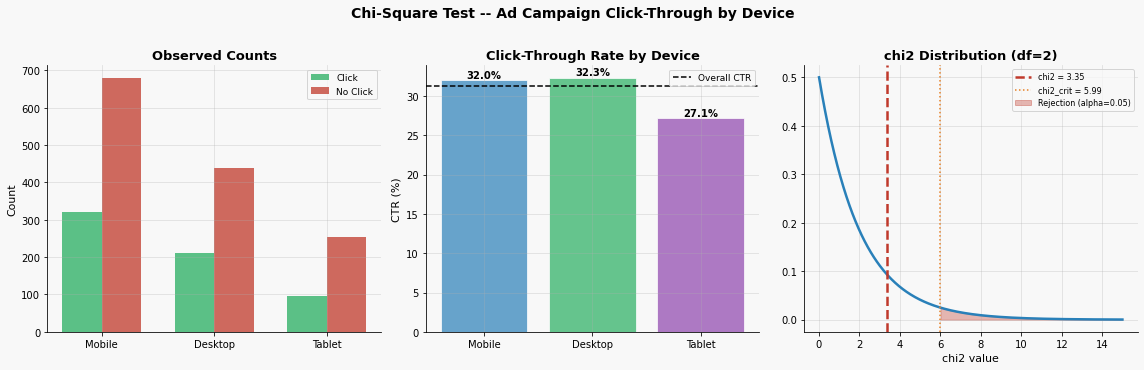

In [23]:
# ── Visualisation ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 1. Grouped bar chart
x = np.arange(len(devices))
width = 0.35
axes[0].bar(x - width/2, observed[:,0], width, color=GREEN, alpha=0.75, label='Click')
axes[0].bar(x + width/2, observed[:,1], width, color=RED,   alpha=0.75, label='No Click')
axes[0].set_xticks(x); axes[0].set_xticklabels(devices)
axes[0].set_title('Observed Counts'); axes[0].set_ylabel('Count')
axes[0].legend(fontsize=9)

# 2. Click-through rate by device
ctrs = [observed[i,0]/observed[i,:].sum()*100 for i in range(3)]
bars = axes[1].bar(devices, ctrs, color=[BLUE,GREEN,PURPLE], alpha=0.7, edgecolor='white')
axes[1].axhline(observed[:,0].sum()/observed.sum()*100, color='black',
                linestyle='--', linewidth=1.5, label='Overall CTR')
for bar, ctr in zip(bars, ctrs):
    axes[1].text(bar.get_x()+bar.get_width()/2, ctr+0.3, f'{ctr:.1f}%',
                 ha='center', fontsize=10, fontweight='bold')
axes[1].set_title('Click-Through Rate by Device'); axes[1].set_ylabel('CTR (%)')
axes[1].legend(fontsize=9)

# 3. Chi-square distribution
x_c = np.linspace(0, 15, 400)
y_c = stats.chi2.pdf(x_c, dof)
chi2_crit = stats.chi2.ppf(0.95, dof)
axes[2].plot(x_c, y_c, color=BLUE, linewidth=2.5)
axes[2].fill_between(x_c, y_c, where=(x_c >= chi2_crit), alpha=0.35, color=RED,
                     label=f'Rejection (alpha=0.05)')
axes[2].axvline(chi2_stat, color=RED, linestyle='--', linewidth=2.5,
                label=f'chi2 = {chi2_stat:.2f}')
axes[2].axvline(chi2_crit, color=ORANGE, linestyle=':', linewidth=1.5,
                label=f'chi2_crit = {chi2_crit:.2f}')
axes[2].set_title(f'chi2 Distribution (df={dof})')
axes[2].set_xlabel('chi2 value'); axes[2].legend(fontsize=8)

plt.suptitle('Chi-Square Test -- Ad Campaign Click-Through by Device', fontsize=14,
             fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()

---
## Chapter 6 -- Chi-Square Goodness of Fit

**Question:** Does an observed distribution match a theoretically expected distribution?

Same formula as before, but expected values come from theory, not the data.

### 🎲 Example: Is this Die Fair?
> A casino inspector rolls a die **120 times** and records each outcome.  
> Under a fair die, each face should appear exactly 1/6 of the time.

- **H₀:** The die is fair (each face equally likely)  
- **H1:** The die is not fair  
- **alpha = 0.05**


In [24]:
# ── Dataset: Die rolls ────────────────────────────────────────
observed_die = np.array([25, 17, 15, 23, 19, 21])   # outcomes 1-6
n_rolls = observed_die.sum()
expected_die = np.full(6, n_rolls / 6)               # 20 each if fair

df_die = pd.DataFrame({
    'Face':     [1, 2, 3, 4, 5, 6],
    'Observed': observed_die,
    'Expected': expected_die.astype(int),
    'Residual': observed_die - expected_die
})
print(df_die.to_string(index=False))
print(f"Total rolls: {n_rolls}")

 Face  Observed  Expected  Residual
    1        25        20       5.0
    2        17        20      -3.0
    3        15        20      -5.0
    4        23        20       3.0
    5        19        20      -1.0
    6        21        20       1.0
Total rolls: 120


In [25]:
# ── STEP 4: Goodness of fit test ──────────────────────────────
chi2_stat, p_value = stats.chisquare(observed_die, f_exp=expected_die)

print_result(
    "Chi-Square Goodness of Fit: Die Fairness Test",
    chi2_stat, "chi2 statistic", p_value,
    extra={"df": f"{len(observed_die)-1}",
           "n (rolls)": f"{n_rolls}"}
)

# Standardised residuals
std_res = (observed_die - expected_die) / np.sqrt(expected_die)
print("Standardised residuals (|r| > 2 -> unusual):")
for face, r in enumerate(std_res, 1):
    flag = " ⚠️" if abs(r) > 2 else ""
    print(f"    Face {face}: {r:+.3f}{flag}")

───────────────────────────────────────────────────────
  Chi-Square Goodness of Fit: Die Fairness Test
───────────────────────────────────────────────────────
  chi2 statistic           :     3.5000
  p-value              :     0.6234
  alpha (significance)     :       0.05
  df                       : 5
  n (rolls)                : 120
───────────────────────────────────────────────────────
  [X] FAIL TO REJECT H₀  (p=0.6234 >= alpha=0.05)
     -> Not enough evidence against H₀.
───────────────────────────────────────────────────────
Standardised residuals (|r| > 2 -> unusual):
    Face 1: +1.118
    Face 2: -0.671
    Face 3: -1.118
    Face 4: +0.671
    Face 5: -0.224
    Face 6: +0.224


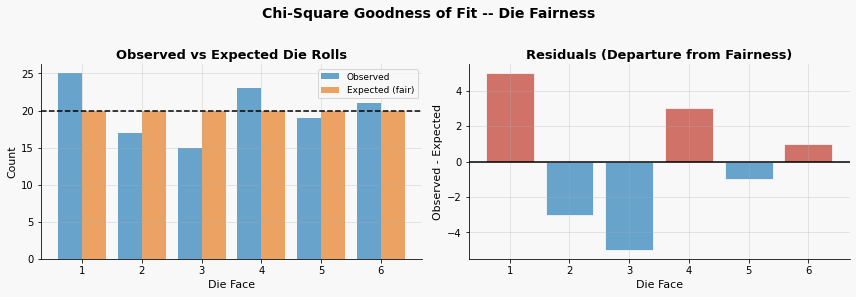

In [26]:
# ── Visualisation ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

x = np.arange(1, 7)
axes[0].bar(x - 0.2, observed_die, 0.4, color=BLUE, alpha=0.7, label='Observed')
axes[0].bar(x + 0.2, expected_die, 0.4, color=ORANGE, alpha=0.7, label='Expected (fair)')
axes[0].axhline(n_rolls/6, color='black', linestyle='--', linewidth=1.5)
axes[0].set_xticks(x); axes[0].set_xlabel('Die Face')
axes[0].set_ylabel('Count'); axes[0].set_title('Observed vs Expected Die Rolls')
axes[0].legend(fontsize=9)

# Residuals
colors_r = [RED if r > 0 else BLUE for r in observed_die - expected_die]
axes[1].bar(x, observed_die - expected_die, color=colors_r, alpha=0.7, edgecolor='white')
axes[1].axhline(0, color='black', linewidth=1.5)
axes[1].set_xticks(x); axes[1].set_xlabel('Die Face')
axes[1].set_ylabel('Observed - Expected')
axes[1].set_title('Residuals (Departure from Fairness)')

plt.suptitle('Chi-Square Goodness of Fit -- Die Fairness', fontsize=14,
             fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()

---
## Chapter 7 -- Pearson Correlation Test

**Question:** Is there a statistically significant linear relationship between two continuous variables?

$$r = \frac{\sum(x_i - \bar{x})(y_i - \bar{y})}{\sqrt{\sum(x_i-\bar{x})^2 \sum(y_i-\bar{y})^2}}, \quad t = \frac{r\sqrt{n-2}}{\sqrt{1-r^2}}$$

- r = +1: perfect positive linear relationship  
- r = 0: no linear relationship  
- r = -1: perfect negative linear relationship

### 📖 Example: Study Hours vs Exam Score
> 40 students tracked their weekly study hours and final exam scores.  
> Does more study time significantly correlate with better performance?

- **H₀:** rho = 0 *(no linear association)*  
- **H1:** rho != 0 *(significant linear association)*  
- **alpha = 0.05**


In [27]:
# ── Dataset ────────────────────────────────────────────────────
np.random.seed(55)
n_students = 40
study_hours = np.round(np.random.uniform(1, 15, n_students), 1)
noise = np.random.normal(0, 8, n_students)
exam_score = np.clip(np.round(45 + 3.2 * study_hours + noise), 0, 100)

df_study = pd.DataFrame({'study_hours': study_hours, 'exam_score': exam_score})
print("── Study Data (first 10 rows) ───────────────────")
print(df_study.head(10).to_string(index=False))
print(f"n = {n_students}")
print(f"  Study hours: min={study_hours.min():.1f}, max={study_hours.max():.1f}, "
      f"mean={study_hours.mean():.1f}")
print(f"  Exam scores: min={exam_score.min():.0f}, max={exam_score.max():.0f}, "
      f"mean={exam_score.mean():.1f}")

── Study Data (first 10 rows) ───────────────────
 study_hours  exam_score
         2.3        49.0
        14.6       100.0
         7.8        72.0
         4.4        63.0
         8.4        70.0
         5.0        57.0
        13.1        90.0
         1.6        58.0
         2.5        63.0
        11.7        86.0
n = 40
  Study hours: min=1.1, max=14.8, mean=8.2
  Exam scores: min=36, max=100, mean=72.0


In [28]:
# ── STEP 4: Pearson correlation test ──────────────────────────
r, p_value = pearsonr(study_hours, exam_score)

# t-statistic for correlation
t_stat_r = r * np.sqrt(n_students - 2) / np.sqrt(1 - r**2)

# R2 -- proportion of variance explained
r_squared = r**2

print_result(
    "Pearson Correlation Test: Study Hours vs Exam Score",
    r, "r (correlation)", p_value,
    extra={
        "t-statistic":    f"{t_stat_r:.4f}",
        "R2 (explained)": f"{r_squared:.4f}  ({r_squared*100:.1f}% of variance)",
        "n":              f"{n_students}",
        "Effect (|r|)":   f"{'Small (<0.3)' if abs(r)<0.3 else 'Medium (<0.5)' if abs(r)<0.5 else 'Large'}"
    }
)

───────────────────────────────────────────────────────
  Pearson Correlation Test: Study Hours vs Exam Score
───────────────────────────────────────────────────────
  r (correlation)          :     0.9011
  p-value              :     0.0000
  alpha (significance)     :       0.05
  t-statistic              : 12.8142
  R2 (explained)           : 0.8121  (81.2% of variance)
  n                        : 40
  Effect (|r|)             : Large
───────────────────────────────────────────────────────
  [OK] REJECT H₀  (p=0.0000 < alpha=0.05)
     -> Statistically significant result.
───────────────────────────────────────────────────────


  Permutation test p-value: 0.0000  (parametric: 0.0000)


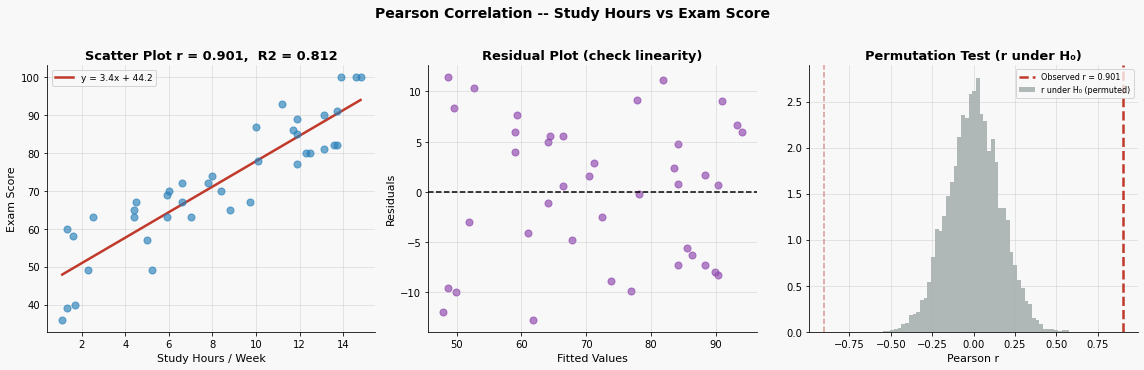

In [30]:
# ── Visualisation ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 1. Scatter with regression line
from numpy.polynomial import polynomial as P
slope, intercept = np.polyfit(study_hours, exam_score, 1)
x_line = np.linspace(study_hours.min(), study_hours.max(), 200)
axes[0].scatter(study_hours, exam_score, color=BLUE, alpha=0.65, s=50, zorder=5)
axes[0].plot(x_line, slope*x_line + intercept, color=RED, linewidth=2.5,
             label=f'y = {slope:.1f}x + {intercept:.1f}')
axes[0].set_xlabel('Study Hours / Week')
axes[0].set_ylabel('Exam Score')
axes[0].set_title(f'Scatter Plot r = {r:.3f},  R2 = {r_squared:.3f}')
axes[0].legend(fontsize=9)

# 2. Residual plot
predicted = slope * study_hours + intercept
residuals = exam_score - predicted
axes[1].scatter(predicted, residuals, color=PURPLE, alpha=0.65, s=50)
axes[1].axhline(0, color='black', linewidth=1.5, linestyle='--')
axes[1].set_xlabel('Fitted Values'); axes[1].set_ylabel('Residuals')
axes[1].set_title('Residual Plot (check linearity)')

# 3. Distribution of r under H₀ vs observed r
n_perm = 5000
r_perm = [pearsonr(np.random.permutation(study_hours), exam_score)[0]
          for _ in range(n_perm)]
axes[2].hist(r_perm, bins=50, color=GREY, alpha=0.6, density=True,edgecolor='none', label='r under H₀ (permuted)')
axes[2].axvline(r, color=RED, linestyle='--', linewidth=2.5,label=f'Observed r = {r:.3f}')
axes[2].axvline(-r, color=RED, linestyle='--', linewidth=1.5, alpha=0.5)
axes[2].set_xlabel('Pearson r'); axes[2].set_title('Permutation Test (r under H₀)')
axes[2].legend(fontsize=8)

perm_p = np.mean(np.abs(r_perm) >= abs(r))
print(f"  Permutation test p-value: {perm_p:.4f}  (parametric: {p_value:.4f})")

plt.suptitle('Pearson Correlation -- Study Hours vs Exam Score', fontsize=14,
             fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()

---
## Chapter 8 -- Mann-Whitney U Test (Non-Parametric)

**Use when:** Two independent groups, but normality assumption is violated, small sample, or ordinal data.

**What it tests:** Whether one group's values tend to be larger than the other's (compares *ranks*, not means).

> Think of it as: "If I picked one person from each group at random, which group is more likely to have the higher value?"

### ⭐ Example: Customer Ratings -- Two Support Teams
> Two customer support teams. Ratings are on a 1-5 scale (ordinal).  
> Team A (30 customers) vs Team B (28 customers).

- **H₀:** Distribution of ratings is the same for both teams  
- **H1:** One team tends to receive higher ratings  
- **alpha = 0.05**


In [31]:
# ── Dataset: Customer ratings (1-5 scale) ─────────────────────
np.random.seed(33)
# Team A: slightly lower rated
team_a = np.random.choice([1,2,3,4,5], size=30,
                           p=[0.05, 0.15, 0.35, 0.30, 0.15])
# Team B: slightly higher rated
team_b = np.random.choice([1,2,3,4,5], size=28,
                           p=[0.02, 0.08, 0.20, 0.40, 0.30])

df_ratings = pd.DataFrame({
    'rating': np.concatenate([team_a, team_b]),
    'team':   ['Team A']*30 + ['Team B']*28
})

print("── Rating Distribution ──────────────────────────")
ct = pd.crosstab(df_ratings['team'], df_ratings['rating'])
ct['Median'] = [np.median(team_a), np.median(team_b)]
print(ct.to_string())

── Rating Distribution ──────────────────────────
rating  1  2   3   4  5  Median
team                           
Team A  1  6  12   5  6     3.0
Team B  0  3   6  12  7     4.0


In [32]:
# ── STEP 2: Check normality (motivation for non-parametric) ───
print("── Normality Check ──────────────────────────────")
check_normality(team_a.astype(float), "Team A")
check_normality(team_b.astype(float), "Team B")
print()
print("  Since data is ordinal and non-normal -> use Mann-Whitney U")

── Normality Check ──────────────────────────────
  Shapiro-Wilk [Team A]:  W=0.8945, p=0.0062  -> ⚠️  May not be normal
  Shapiro-Wilk [Team B]:  W=0.8652, p=0.0019  -> ⚠️  May not be normal

  Since data is ordinal and non-normal -> use Mann-Whitney U


In [33]:
# ── STEP 4: Mann-Whitney U test ────────────────────────────────
u_stat, p_value = mannwhitneyu(team_a, team_b, alternative='two-sided')

# Effect size r = Z / sqrt(N)
n_total = len(team_a) + len(team_b)
z_stat = (u_stat - len(team_a)*len(team_b)/2) / np.sqrt(
    len(team_a)*len(team_b)*(n_total+1)/12)
effect_r = abs(z_stat) / np.sqrt(n_total)

print_result(
    "Mann-Whitney U Test: Customer Ratings Team A vs Team B",
    u_stat, "U-statistic", p_value,
    extra={
        "Team A median": f"{np.median(team_a):.1f}",
        "Team B median": f"{np.median(team_b):.1f}",
        "Z-score":       f"{z_stat:.4f}",
        "Effect size r": f"{effect_r:.4f}  ({'small' if effect_r<0.3 else 'medium' if effect_r<0.5 else 'large'})"
    }
)

───────────────────────────────────────────────────────
  Mann-Whitney U Test: Customer Ratings Team A vs Team B
───────────────────────────────────────────────────────
  U-statistic              :   303.0000
  p-value              :     0.0602
  alpha (significance)     :       0.05
  Team A median            : 3.0
  Team B median            : 4.0
  Z-score                  : -1.8206
  Effect size r            : 0.2391  (small)
───────────────────────────────────────────────────────
  [X] FAIL TO REJECT H₀  (p=0.0602 >= alpha=0.05)
     -> Not enough evidence against H₀.
───────────────────────────────────────────────────────


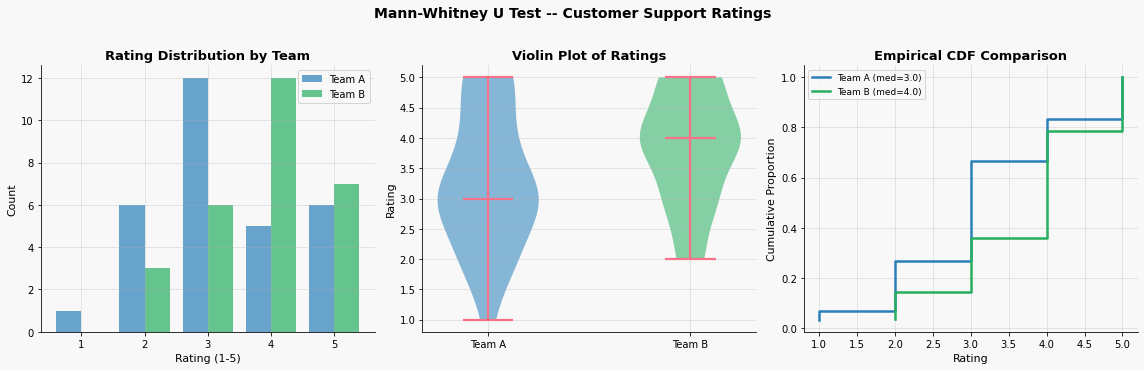

In [34]:
# ── Visualisation ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 1. Count plots
for i, (team, data, color) in enumerate(
        [('Team A', team_a, BLUE), ('Team B', team_b, GREEN)]):
    vals, counts = np.unique(data, return_counts=True)
    offset = -0.2 + i*0.4
    axes[0].bar(vals + offset, counts, 0.4, color=color, alpha=0.7, label=team)
axes[0].set_xticks([1,2,3,4,5])
axes[0].set_xlabel('Rating (1-5)'); axes[0].set_ylabel('Count')
axes[0].set_title('Rating Distribution by Team'); axes[0].legend()

# 2. Violin plot
parts = axes[1].violinplot([team_a, team_b], positions=[1,2],
                            showmedians=True, showextrema=True)
for pc, color in zip(parts['bodies'], [BLUE, GREEN]):
    pc.set_facecolor(color); pc.set_alpha(0.55)
axes[1].set_xticks([1,2])
axes[1].set_xticklabels(['Team A', 'Team B'])
axes[1].set_ylabel('Rating'); axes[1].set_title('Violin Plot of Ratings')

# 3. Cumulative distribution comparison
for data, color, label in [(team_a, BLUE, f'Team A (med={np.median(team_a):.1f})'),
                            (team_b, GREEN, f'Team B (med={np.median(team_b):.1f})')]:
    sorted_d = np.sort(data)
    cdf = np.arange(1, len(sorted_d)+1) / len(sorted_d)
    axes[2].step(sorted_d, cdf, color=color, linewidth=2.5, label=label)
axes[2].set_xlabel('Rating'); axes[2].set_ylabel('Cumulative Proportion')
axes[2].set_title('Empirical CDF Comparison'); axes[2].legend(fontsize=9)

plt.suptitle('Mann-Whitney U Test -- Customer Support Ratings', fontsize=14,
             fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()

---
## Chapter 9 -- Wilcoxon Signed-Rank Test (Non-Parametric Paired)

**Use when:** Paired/before-after design, but normality of differences is violated.  
Non-parametric alternative to the paired t-test.

**How it works:** Ranks the *absolute differences*, then tests whether positive and negative ranks are balanced.

### 📱 Example: App Usability Score Before/After Redesign
> 20 users rated an app's usability (0-100) before and after a UI redesign.  
> Scores are bounded, potentially skewed -- not safe to assume normality.

- **H₀:** Median difference = 0 *(redesign had no effect)*  
- **H1:** Median difference != 0  
- **alpha = 0.05**


In [36]:
# ── Dataset ────────────────────────────────────────────────────
np.random.seed(99)
n_users = 20
before_app = np.round(np.random.beta(4, 3, n_users) * 100).astype(int)
diff_app   = np.round(np.random.beta(3, 2, n_users) * 20 - 5).astype(int)
after_app  = np.clip(before_app + diff_app, 0, 100)

df_app = pd.DataFrame({
    'user':   [f'U{i+1:02d}' for i in range(n_users)],
    'before': before_app,
    'after':  after_app,
    'diff':   after_app - before_app
})

print("── Usability Scores ─────────────────────────────")
print(df_app.to_string(index=False))
print(f"Median before: {np.median(before_app):.1f}")
print(f"  Median after:  {np.median(after_app):.1f}")
print(f"  Median diff:   {np.median(after_app - before_app):.1f}")

── Usability Scores ─────────────────────────────
user  before  after  diff
 U01      31     31     0
 U02      44     52     8
 U03      56     61     5
 U04      46     58    12
 U05      82     97    15
 U06      43     44     1
 U07      49     59    10
 U08      47     48     1
 U09      47     58    11
 U10      49     54     5
 U11      58     71    13
 U12      36     45     9
 U13      81     87     6
 U14      87     89     2
 U15      33     38     5
 U16      82     83     1
 U17      56     64     8
 U18      75     82     7
 U19      60     66     6
 U20      30     33     3
Median before: 49.0
  Median after:  58.5
  Median diff:   6.0


In [37]:
# ── STEP 2: Check normality of differences ────────────────────
print("── Normality of Differences ─────────────────────")
check_normality(df_app['diff'].values, "diff")
print("(If not normal -> Wilcoxon is preferred over paired t-test)")

── Normality of Differences ─────────────────────
  Shapiro-Wilk [diff]:  W=0.9599, p=0.5424  -> [OK] Likely normal
(If not normal -> Wilcoxon is preferred over paired t-test)


In [38]:
# ── STEP 4: Wilcoxon signed-rank test ─────────────────────────
w_stat, p_value = wilcoxon(after_app, before_app, alternative='two-sided')

print_result(
    "Wilcoxon Signed-Rank Test: App Usability Before vs After Redesign",
    w_stat, "W-statistic", p_value,
    extra={
        "Median before":   f"{np.median(before_app):.1f}",
        "Median after":    f"{np.median(after_app):.1f}",
        "Median diff":     f"{np.median(after_app-before_app):.1f}",
        "Positive diffs":  f"{(df_app['diff']>0).sum()} / {n_users}",
        "Negative diffs":  f"{(df_app['diff']<0).sum()} / {n_users}",
    }
)

───────────────────────────────────────────────────────
  Wilcoxon Signed-Rank Test: App Usability Before vs After Redesign
───────────────────────────────────────────────────────
  W-statistic              :     0.0000
  p-value              :     0.0001
  alpha (significance)     :       0.05
  Median before            : 49.0
  Median after             : 58.5
  Median diff              : 6.0
  Positive diffs           : 19 / 20
  Negative diffs           : 0 / 20
───────────────────────────────────────────────────────
  [OK] REJECT H₀  (p=0.0001 < alpha=0.05)
     -> Statistically significant result.
───────────────────────────────────────────────────────


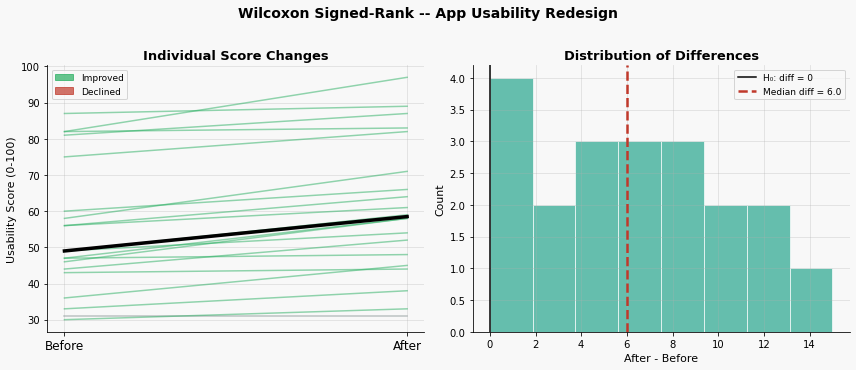

In [40]:
import matplotlib.patches as mpatches
# ── Visualisation ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# 1. Before/after per user
for _, row in df_app.iterrows():
    c = GREEN if row['diff'] > 0 else (RED if row['diff'] < 0 else GREY)
    axes[0].plot([0, 1], [row['before'], row['after']], color=c, alpha=0.5, linewidth=1.5)
axes[0].plot([0,1],[np.median(before_app),np.median(after_app)],
             color='black', linewidth=3.5, zorder=5, label='Median')
axes[0].set_xticks([0,1]); axes[0].set_xticklabels(['Before','After'], fontsize=12)
axes[0].set_ylabel('Usability Score (0-100)')
axes[0].set_title('Individual Score Changes')
axes[0].legend(fontsize=9)

g_patch = mpatches.Patch(color=GREEN, alpha=0.7, label='Improved')
r_patch = mpatches.Patch(color=RED,   alpha=0.7, label='Declined')
axes[0].legend(handles=[g_patch, r_patch], fontsize=9)

# 2. Differences histogram
diffs_app = df_app['diff'].values
axes[1].hist(diffs_app, bins=8, color=TEAL, alpha=0.65, edgecolor='white')
axes[1].axvline(0, color='black', linestyle='-', linewidth=1.5, label='H₀: diff = 0')
axes[1].axvline(np.median(diffs_app), color=RED, linestyle='--', linewidth=2.5,
                label=f'Median diff = {np.median(diffs_app):.1f}')
axes[1].set_xlabel('After - Before'); axes[1].set_ylabel('Count')
axes[1].set_title('Distribution of Differences'); axes[1].legend(fontsize=9)

plt.suptitle('Wilcoxon Signed-Rank -- App Usability Redesign', fontsize=14,
             fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()



---
## Chapter 10 -- Choosing the Right Test

The biggest practical challenge is picking the correct test. Use this framework.


In [41]:
# ── Decision framework as a lookup table ──────────────────────
framework = pd.DataFrame([
    ["Compare sample mean to a value",   "Continuous", "1 group",   "Normal",     "One-Sample t-Test",       "Sign Test"],
    ["Compare 2 independent group means","Continuous", "2 groups",  "Normal+EqV", "Independent t-Test",      "Mann-Whitney U"],
    ["Compare 2 independent group means","Continuous", "2 groups",  "Normal",     "Welch's t-Test",          "Mann-Whitney U"],
    ["Compare before/after same subjects","Continuous","2 measures","Normal diff","Paired t-Test",           "Wilcoxon Signed-Rank"],
    ["Compare 3+ group means",           "Continuous", "3+ groups", "Normal+EqV", "One-Way ANOVA",           "Kruskal-Wallis"],
    ["Association between categoricals", "Categorical","2+ vars",   "Exp >= 5",    "Chi-Square Independence",  "Fisher's Exact"],
    ["Does data fit a distribution?",    "Categorical","1 var",     "Exp >= 5",    "Chi-Square Goodness of Fit","--"],
    ["Linear relationship?",             "Continuous", "2 vars",    "Bivariate N","Pearson Correlation",     "Spearman/Kendall"],
    ["Rank relationship?",               "Ordinal",    "2 vars",    "None",       "Spearman Correlation",    "Kendall's Tau"],
], columns=["Goal", "Data Type", "Structure", "Assumption", "Parametric Test", "Non-Parametric Alt"])

pd.set_option('display.max_colwidth', 40)
pd.set_option('display.width', 120)
print("HYPOTHESIS TEST DECISION TABLE")
print("=" * 120)
print(framework.to_string(index=False))

HYPOTHESIS TEST DECISION TABLE
                              Goal   Data Type  Structure  Assumption            Parametric Test   Non-Parametric Alt
    Compare sample mean to a value  Continuous    1 group      Normal          One-Sample t-Test            Sign Test
 Compare 2 independent group means  Continuous   2 groups  Normal+EqV         Independent t-Test       Mann-Whitney U
 Compare 2 independent group means  Continuous   2 groups      Normal             Welch's t-Test       Mann-Whitney U
Compare before/after same subjects  Continuous 2 measures Normal diff              Paired t-Test Wilcoxon Signed-Rank
            Compare 3+ group means  Continuous  3+ groups  Normal+EqV              One-Way ANOVA       Kruskal-Wallis
  Association between categoricals Categorical    2+ vars    Exp >= 5    Chi-Square Independence       Fisher's Exact
     Does data fit a distribution? Categorical      1 var    Exp >= 5 Chi-Square Goodness of Fit                   --
              Linear rela

In [42]:
# ── Assumption checking guide ──────────────────────────────────
lines = [
    "+==============================================================+",
    "|              ASSUMPTION CHECKING WORKFLOW                    |",
    "+==============================================================+",
    "|  1. NORMALITY                                                |",
    "|     * n < 30  -> Shapiro-Wilk test + Q-Q plot               |",
    "|     * n >= 30 -> CLT applies; normality less critical        |",
    "|     * Violated -> use non-parametric alternative             |",
    "|  2. EQUAL VARIANCES (for independent t-test / ANOVA)        |",
    "|     * Levene's test or Bartlett's test                       |",
    "|     * Violated -> Welch's t-test / Welch's ANOVA             |",
    "|  3. INDEPENDENCE                                             |",
    "|     * Study design question (not a statistical test)         |",
    "|     * Are observations collected separately?                 |",
    "|  4. EXPECTED FREQUENCIES (chi-square)                        |",
    "|     * All expected cells must be >= 5                        |",
    "|     * If violated -> Fisher's Exact Test                     |",
    "|  5. SAMPLE SIZE                                              |",
    "|     * Very small (n < 10) -> be very cautious                |",
    "|     * Consider exact tests                                   |",
    "+==============================================================+",
]
print("".join(lines))

+==============================================================+|              ASSUMPTION CHECKING WORKFLOW                    |+==============================================================+|  1. NORMALITY                                                ||     * n < 30  -> Shapiro-Wilk test + Q-Q plot               ||     * n >= 30 -> CLT applies; normality less critical        ||     * Violated -> use non-parametric alternative             ||  2. EQUAL VARIANCES (for independent t-test / ANOVA)        ||     * Levene's test or Bartlett's test                       ||     * Violated -> Welch's t-test / Welch's ANOVA             ||  3. INDEPENDENCE                                             ||     * Study design question (not a statistical test)         ||     * Are observations collected separately?                 ||  4. EXPECTED FREQUENCIES (chi-square)                        ||     * All expected cells must be >= 5                        ||     * If violated -> Fisher's Exact Test

In [43]:
# ── Common interpretation mistakes to avoid ────────────────────
pitfalls = [
    "+==============================================================+",
    "|              INTERPRETATION PITFALLS                         |",
    "+==============================================================+",
    "| WRONG: p<0.05 means the effect is large or important         |",
    "| RIGHT: Statistical sig != practical significance             |",
    "|        Always report effect size (Cohen d, r, eta-sq)        |",
    "| WRONG: p>0.05 means H0 is true / no effect exists            |",
    "| RIGHT: Insufficient evidence -- may be underpowered          |",
    "| WRONG: p=0.03 means 3% chance H0 is true                     |",
    "| RIGHT: p = P(data this extreme | H0 true)                    |",
    "| WRONG: Running many tests without correction                  |",
    "| RIGHT: Use Bonferroni / FDR for multiple comparisons         |",
    "| WRONG: Look at data first, then decide what to test           |",
    "| RIGHT: Pre-register hypothesis; set alpha BEFORE seeing p    |",
    "+==============================================================+",
]
print(chr(10).join(pitfalls))

+==============================================================+
|              INTERPRETATION PITFALLS                         |
+==============================================================+
| WRONG: p<0.05 means the effect is large or important         |
| RIGHT: Statistical sig != practical significance             |
|        Always report effect size (Cohen d, r, eta-sq)        |
| WRONG: p>0.05 means H0 is true / no effect exists            |
| RIGHT: Insufficient evidence -- may be underpowered          |
| WRONG: p=0.03 means 3% chance H0 is true                     |
| RIGHT: p = P(data this extreme | H0 true)                    |
| WRONG: Running many tests without correction                  |
| RIGHT: Use Bonferroni / FDR for multiple comparisons         |
| WRONG: Look at data first, then decide what to test           |
| RIGHT: Pre-register hypothesis; set alpha BEFORE seeing p    |
+==============================================================+
